# Step 5f: Visualizing Fingerprint Bit Environments
Explanation Script: "Let's visually see what bit 2 looks like in chloroquine. We'll highlight the atoms that contribute to this bit."

Bit 2 highlights these atoms (in red):


[21:05:44] DEPRECATION WARNING: please use MorganGenerator


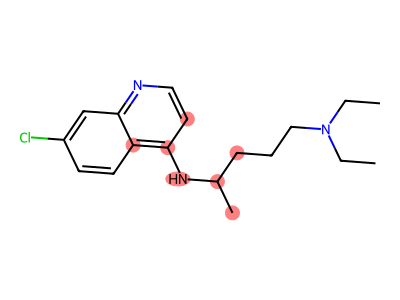

Highlighted atoms: [7, 8, 9, 10, 11, 12, 20]


In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import SimilarityMaps
import matplotlib.pyplot as plt

# Chloroquine 
smiles = "CCN(CC)CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl"
mol = Chem.MolFromSmiles(smiles)

# Generate fingerprint with bit info
bit_info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=128, bitInfo=bit_info)

# Function to highlight atoms contributing to a specific bit
def highlight_bit(mol, bit, bit_info):
    if bit not in bit_info:
        print(f"Bit {bit} is 0 in this molecule")
        return None
    
    # Get all atoms involved in this bit
    atoms_to_highlight = set()
    for atom_idx, radius in bit_info[bit]:
        # Get environment atoms
        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
        amap = {}
        submol = Chem.PathToSubmol(mol, env, atomMap=amap)
        atoms_to_highlight.update(amap.keys())
    
    return list(atoms_to_highlight)

# Highlight atoms for bit 2
highlight_atoms = highlight_bit(mol, 2, bit_info)
if highlight_atoms:
    img = Draw.MolToImage(mol, size=(400, 300), highlightAtoms=highlight_atoms)
    print("Bit 2 highlights these atoms (in red):")
    display(img)
    print(f"Highlighted atoms: {sorted(highlight_atoms)}")




Explanation Script Continues:

"The red atoms are the ones responsible for activating bit 2 = 1 in the chloroquine fingerprint. Notice that they form a connected environment that includes part of the quinoline aromatic ring and the beginning of the side chain attached to it.

These highlighted atoms correspond to the atom environment centered around atom 10 with radius 2, which includes atoms [7, 8, 9, 10, 11, 12, 20]. This environment captures the local connectivity pattern around the nitrogen-containing ring system and the adjacent carbon atoms.

Because Morgan fingerprints examine the neighborhood around each atom, the algorithm detects this particular structural pattern and assigns it to bit 2 in the fingerprint vector.

This demonstrates an important idea: fingerprint bits represent chemical environments rather than single atoms or single functional groups. Whenever a molecule contains an environment with the same connectivity pattern, the corresponding fingerprint bit becomes active.

Machine learning models then use these fingerprint patterns as features, allowing them to compare molecules and identify structural characteristics that correlate with biological activity, such as the antimalarial activity of chloroquine."